In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

# Analysis for PD participants

In [2]:
#load the data
df_plot = pd.read_csv('df_longitudinalAnalysis_PD.csv')

/var/folders/b1/0bxnwlr92xn3yw13pc6vgx6w0000gn/T/ipykernel_59948/1693619001.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(ids))


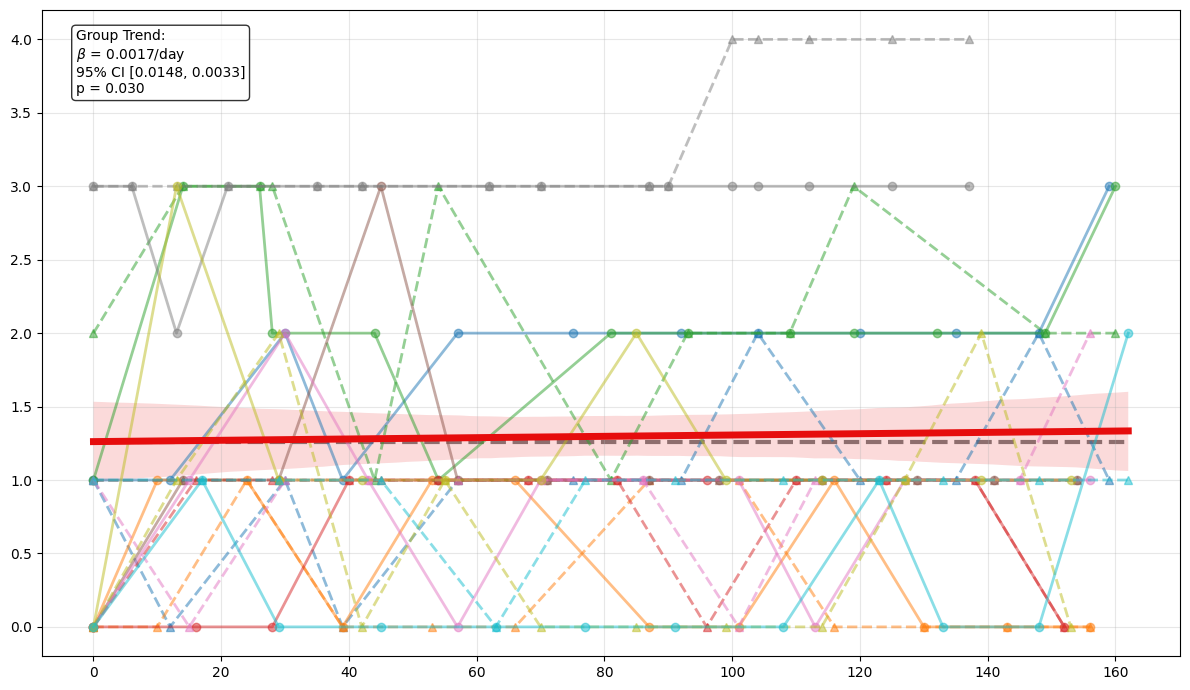

In [7]:
#plot progression of Clinical Score over time for each patient, with a group-trend line

fig, ax = plt.subplots(figsize=(12, 7))

ids = df_plot["PatientID"].unique()
cmap = plt.cm.get_cmap("tab10", len(ids))
for i, pid in enumerate(sorted(ids)):
    p = df_plot[df_plot["PatientID"] == pid]

    for side_name, line_style, marker in [("Right", "-","o"), ("Left", "--","^")]:
        s = p[
            p["Side"].astype(str).str.strip().str.upper() == side_name.upper()
        ].sort_values("DaysFromBaseline")

        if s.empty:
            
            continue

        ax.plot(
            s["DaysFromBaseline"],
            s["Clinical_Score"],
            marker=marker,
            linestyle=line_style,
            linewidth=2,
            color=cmap(i),
            alpha=0.5,
            # label=f"{pid} - {side_name}"
        )

ax.text( 0.03, 0.97, f"Group Trend:\n$\\beta$ = {  0.0017090933862470767 :.4f}/day\n" f"95% CI [{0.014830:.4f}, {0.003256:.4f}]\n" f"p = {0.03035046482900671:.3f}", transform=ax.transAxes, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8) ) 

sns.regplot(x="DaysFromBaseline", y="Clinical_Score", data=df_plot, scatter=False, ax=ax, color="#E60D0D", line_kws={"linewidth": 5, "linestyle": "-", "zorder": 5}, label=f'Group trend\n(β={0.0017090933862470767:.4f}/day, p={0.03035046482900671:.3f})')
# Straight group-trend line starting at the y-axis intersection (x=0)

slope, intercept, r_value, p_value, std_err = stats.linregress(df_plot["DaysFromBaseline"], df_plot["Clinical_Score"])
x0 = 0
x1 = float(df_plot["DaysFromBaseline"].max())

x_line = np.array([x0, x1])
y_line = intercept + 0 * (x_line - x0)


ax.plot(x_line, y_line, color='k', linewidth=3, linestyle="--", zorder=-6, alpha=0.5)

ax.set_xlabel("", fontsize=16)
ax.set_ylabel("", fontsize=16)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

/var/folders/b1/0bxnwlr92xn3yw13pc6vgx6w0000gn/T/ipykernel_59948/638460065.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(ids))


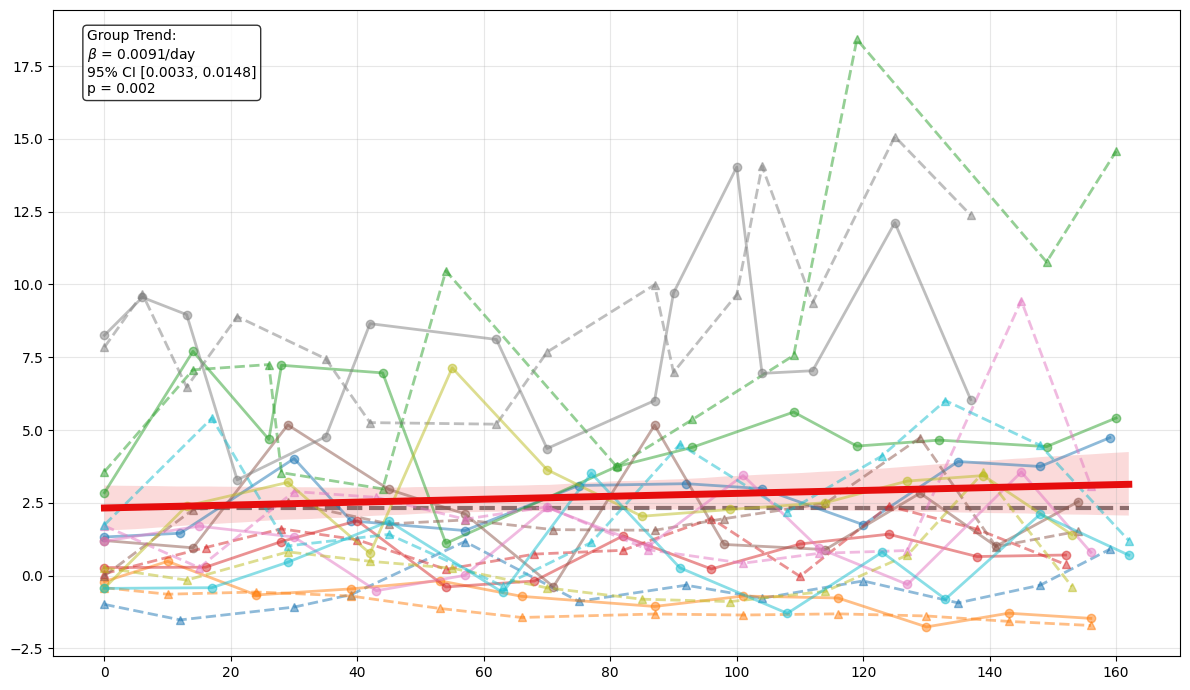

In [8]:
#plot progression of Final Score over time for each patient, with a group-trend line
fig, ax = plt.subplots(figsize=(12, 7))
ids = df_plot["PatientID"].unique()
cmap = plt.cm.get_cmap("tab10", len(ids))

for i, pid in enumerate(sorted(ids)):
    p = df_plot[df_plot["PatientID"] == pid]

    for side_name, line_style, marker in [("Right", "-","o"), ("Left", "--","^")]:
        s = p[
            p["Side"].astype(str).str.strip().str.upper() == side_name.upper()
        ].sort_values("DaysFromBaseline")

        if s.empty:
            
            continue

        ax.plot(
            s["DaysFromBaseline"],
            s["Final_Score"],
            marker=marker,
            linestyle=line_style,
            linewidth=2,
            color=cmap(i),
            alpha=0.5,
            # label=f"{pid} - {side_name}"
        )

ax.text( 0.03, 0.97, f"Group Trend:\n$\\beta$ = {  0.009080122258172877 :.4f}/day\n" f"95% CI [{0.003321:.4f}, {0.014805:.4f}]\n" f"p = {0.0019937411805086734:.3f}", transform=ax.transAxes, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8) ) 

sns.regplot(x="DaysFromBaseline", y="Final_Score", data=df_plot, scatter=False, ax=ax, color="#E60D0D", line_kws={"linewidth": 5, "linestyle": "-", "zorder": 5}, label=f'Group trend\n(β={0.009163190570879689:.4f}/day, p={0.002077626371016603:.3f})')
# Straight group-trend line starting at the y-axis intersection (x=0)

slope, intercept, r_value, p_value, std_err = stats.linregress(df_plot["DaysFromBaseline"], df_plot["Final_Score"])
x0 = 0
x1 = float(df_plot["DaysFromBaseline"].max())

x_line = np.array([x0, x1])
y_line = intercept + 0 * (x_line - x0)


ax.plot(x_line, y_line, color='k', linewidth=3, linestyle="--", zorder=-6, alpha=0.5)

ax.set_xlabel("", fontsize=16)
ax.set_ylabel("", fontsize=16)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Statistical Modeling 

In [12]:
# var = 'Clinical_Score' #uncomment to test Clinical Score instead of Final Score
var = 'Final_Score' # uncomment to test Final Score instead of Clinical Score
# Group-level longitudinal test (accounts for repeated measures within patient)
df_group = df_plot[["PatientID", "MostAffectedSide", "Age", 'Sex', "DaysFromBaseline", "Side", var]].copy()

df_group["DaysFromBaseline"] = pd.to_numeric(df_group["DaysFromBaseline"], errors="coerce")
df_group[var] = pd.to_numeric(df_group[var], errors="coerce")
df_group = df_group.dropna(subset=["PatientID", "MostAffectedSide", "DaysFromBaseline", var])
    
# Mixed-effects model: fixed effect of time, random intercept by patient
df_group["Age"] = pd.to_numeric(df_group["Age"], errors="coerce")
df_group = df_group.dropna(subset=["Age"])
model = smf.mixedlm(
    # f"{var} ~ DaysFromBaseline + C(MostAffectedSide)  + Age + C(Sex)",
    f"{var} ~ DaysFromBaseline + Age + C(Sex)",
    data=df_group,
    groups=df_group["PatientID"],
    re_formula="~1",
)
result = model.fit(reml=True)
print(result.summary())

beta_time = result.params.get("DaysFromBaseline", np.nan)
p_time = result.pvalues.get("DaysFromBaseline", np.nan)
print(f"\nTime effect of {var} (DaysFromBaseline): beta={beta_time:.3f}, p={p_time:.3f}")

if p_time < 0.05:
    print(f"Conclusion: {var} changes significantly over time at the group level.")
else:
    print(f"Conclusion: No significant group-level change in {var} over time.")

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  Final_Score
No. Observations:  223      Method:              REML       
No. Groups:        9        Scale:               4.6251     
Min. group size:   24       Log-Likelihood:      -506.4929  
Max. group size:   30       Converged:           Yes        
Mean group size:   24.8                                     
------------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------
Intercept        -2.861   10.910 -0.262 0.793 -24.244 18.522
C(Sex)[T.1]      -0.682    2.292 -0.297 0.766  -5.174  3.811
DaysFromBaseline  0.009    0.003  3.091 0.002   0.003  0.015
Age               0.086    0.182  0.473 0.636  -0.270  0.443
Group Var        10.866    3.005                            


Time effect of Final_Score (DaysFromBaseline): beta=0.009, p=0.002
Conclusion: Final_Score chan

## Analysis for HC participants

In [15]:
#load the data
df_plot = pd.read_csv('df_longitudinalAnalysis_HC.csv')

/var/folders/b1/0bxnwlr92xn3yw13pc6vgx6w0000gn/T/ipykernel_59948/1108031181.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(ids))


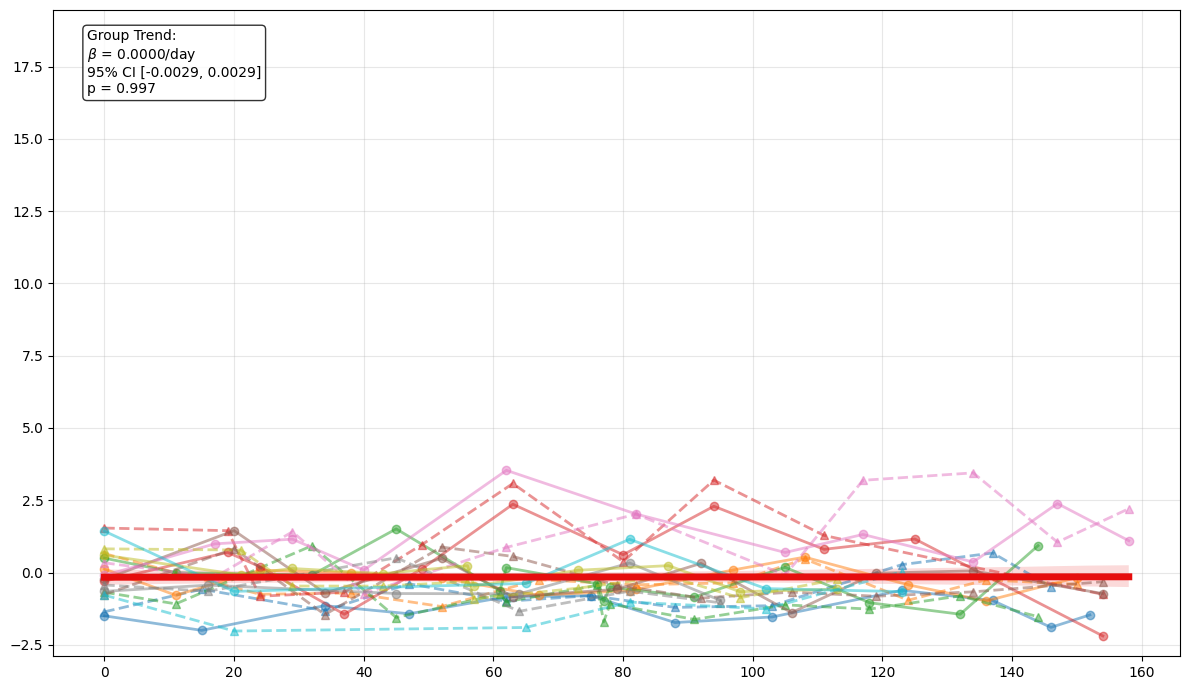

In [20]:
#plot progression of Final Score over time for each patient, with a group-trend line
fig, ax = plt.subplots(figsize=(12, 7))
ids = df_plot["PatientID"].unique()
cmap = plt.cm.get_cmap("tab10", len(ids))

for i, pid in enumerate(sorted(ids)):
    p = df_plot[df_plot["PatientID"] == pid]

    for side_name, line_style, marker in [("Right", "-","o"), ("Left", "--","^")]:
        s = p[
            p["Side"].astype(str).str.strip().str.upper() == side_name.upper()
        ].sort_values("DaysFromBaseline")

        if s.empty:
            
            continue

        ax.plot(
            s["DaysFromBaseline"],
            s["Final_Score"],
            marker=marker,
            linestyle=line_style,
            linewidth=2,
            color=cmap(i),
            alpha=0.5,
            # label=f"{pid} - {side_name}"
        )

ax.text( 0.03, 0.97, f"Group Trend:\n$\\beta$ = {  5.170712022230174e-06 :.4f}/day\n" f"95% CI [{-0.002898:.4f}, {0.002908:.4f}]\n" f"p = {0.9972143069824859:.3f}", transform=ax.transAxes, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8) ) 

sns.regplot(x="DaysFromBaseline", y="Final_Score", data=df_plot, scatter=False, ax=ax, color="#E60D0D", line_kws={"linewidth": 5, "linestyle": "-", "zorder": 5}, label=f'Group trend\n(β={0.009163190570879689:.4f}/day, p={0.002077626371016603:.3f})')
# Straight group-trend line starting at the y-axis intersection (x=0)

slope, intercept, r_value, p_value, std_err = stats.linregress(df_plot["DaysFromBaseline"], df_plot["Final_Score"])
x0 = 0
x1 = float(df_plot["DaysFromBaseline"].max())

x_line = np.array([x0, x1])
y_line = intercept + 0 * (x_line - x0)

ax.plot(x_line, y_line, color='k', linewidth=3, linestyle="--", zorder=-6, alpha=0.5)
plt.ylim([-2.8960948840619913, 19.45719829810702])

plt.yticks([-2.5,0,2.5,5,7.5,10,12.5,15,17.5])
ax.set_xlabel("", fontsize=16)
ax.set_ylabel("", fontsize=16)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
# var = 'Clinical_Score' #uncomment to test Clinical Score instead of Final Score
var = 'Final_Score' # uncomment to test Final Score instead of Clinical Score
# Group-level longitudinal test (accounts for repeated measures within patient)
df_group = df_plot[["PatientID", "MostAffectedSide", "Age", 'Sex', "DaysFromBaseline", "Side", var]].copy()

df_group["DaysFromBaseline"] = pd.to_numeric(df_group["DaysFromBaseline"], errors="coerce")
df_group[var] = pd.to_numeric(df_group[var], errors="coerce")
df_group = df_group.dropna(subset=["PatientID", "MostAffectedSide", "DaysFromBaseline", var])
    
# Mixed-effects model: fixed effect of time, random intercept by patient
df_group["Age"] = pd.to_numeric(df_group["Age"], errors="coerce")
df_group = df_group.dropna(subset=["Age"])
model = smf.mixedlm(
    # f"{var} ~ DaysFromBaseline + C(MostAffectedSide)  + Age + C(Sex)",
    f"{var} ~ DaysFromBaseline + Age + C(Sex)",
    data=df_group,
    groups=df_group["PatientID"],
    re_formula="~1",
)
result = model.fit(reml=True)
print(result.summary())

beta_time = result.params.get("DaysFromBaseline", np.nan)
p_time = result.pvalues.get("DaysFromBaseline", np.nan)
print(f"\nTime effect of {var} (DaysFromBaseline): beta={beta_time:.3f}, p={p_time:.3f}")

if p_time < 0.05:
    print(f"Conclusion: {var} changes significantly over time at the group level.")
else:
    print(f"Conclusion: No significant group-level change in {var} over time.")

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  Final_Score
No. Observations:  173      Method:              REML       
No. Groups:        8        Scale:               0.7547     
Min. group size:   12       Log-Likelihood:      -237.8217  
Max. group size:   28       Converged:           Yes        
Mean group size:   21.6                                     
------------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
------------------------------------------------------------
Intercept        -3.405    5.075 -0.671 0.502 -13.353  6.542
C(Sex)[T.1]      -0.233    0.597 -0.391 0.696  -1.404  0.937
DaysFromBaseline -0.000    0.001 -0.101 0.919  -0.003  0.003
Age               0.057    0.085  0.674 0.501  -0.109  0.224
Group Var         0.613    0.482                            


Time effect of Final_Score (DaysFromBaseline): beta=-0.000, p=0.919
Conclusion: No significant 